## Question 1

In [1]:
import pandas as pd
import numpy as np

In [2]:
np.random.seed(42)

n = 200

data = pd.DataFrame({
    "account_age": np.random.randint(1, 60, n),
    "monthly_bill": np.round(np.random.uniform(20, 200, n), 2),
    "support_calls": np.random.randint(0, 10, n),
    "contract": np.random.randint(0, 2, n),
    "churn": np.random.choice([0, 1], n, p=[0.85, 0.15])
})

In [3]:
print(data.describe())
print("Churn rate:", data['churn'].mean().round(3))

       account_age  monthly_bill  support_calls    contract       churn
count   200.000000    200.000000      200.00000  200.000000  200.000000
mean     29.190000    108.494100        4.60500    0.475000    0.120000
std      16.735119     51.305718        3.00234    0.500628    0.325777
min       1.000000     20.090000        0.00000    0.000000    0.000000
25%      15.000000     66.027500        2.00000    0.000000    0.000000
50%      28.500000    102.245000        4.00000    0.000000    0.000000
75%      43.250000    148.315000        7.00000    1.000000    0.000000
max      59.000000    199.590000        9.00000    1.000000    1.000000
Churn rate: 0.12


In [4]:
data['churn'].value_counts()

churn
0    176
1     24
Name: count, dtype: int64

In [5]:
data.groupby('churn')['monthly_bill'].mean()

churn
0    109.097500
1    104.069167
Name: monthly_bill, dtype: float64

## Question 2

In [6]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

X = data[["account_age", "monthly_bill", "support_calls", "contract"]].values
y = data["churn"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = SGDClassifier(
    loss="log_loss",
    learning_rate="optimal",
    max_iter=200,
    random_state=42
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.43      0.57        35
           1       0.09      0.40      0.15         5

    accuracy                           0.42        40
   macro avg       0.46      0.41      0.36        40
weighted avg       0.74      0.42      0.51        40



## Question 3

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

proba = svm.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, proba)

print(f"RBF-SVM AUC: {auc:.3f}")
print(f"Support vectors per class: {svm.n_support_}")

RBF-SVM AUC: 0.069
Support vectors per class: [49 19]


/Users/vishalbhaga/Documents/University/Year 1/MIT801/Exam/ML/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [8]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define values to search C and gamma
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1]
}

# Create model
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

# Define cross validation with stratification (ensures class balance in splits)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Create grid search class using AUC of ROC curve as scoring metric
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)

Best parameters: {'C': 0.1, 'gamma': 1}


/Users/vishalbhaga/Documents/University/Year 1/MIT801/Exam/ML/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/vishalbhaga/Documents/University/Year 1/MIT801/Exam/ML/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/vishalbhaga/Documents/University/Year 1/MIT801/Exam/ML/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/vishal

## Question 4

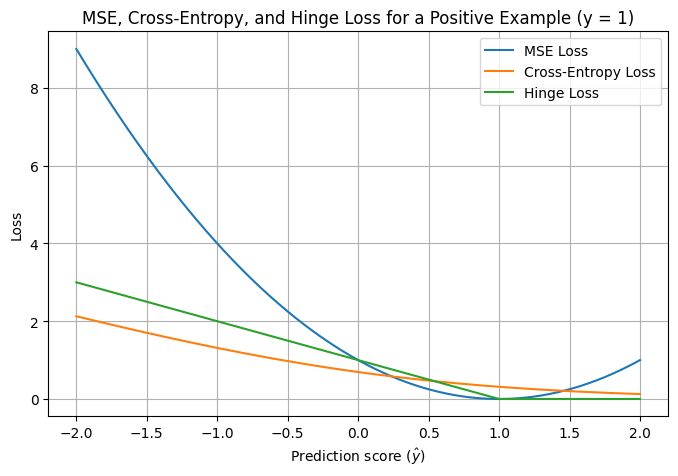

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Prediction scores from -2 to 2
y_pred = np.linspace(-2, 2, 500)

# Positive example
y_true = 1

# Sigmoid function for cross-entropy
def sigmoid_func(z):
    return 1 / (1 + np.exp(-z))

# Loss functions
mse = (y_pred - y_true) ** 2
cross_entropy = -np.log(sigmoid_func(y_pred))
hinge = np.maximum(0, 1 - y_true * y_pred)

# Plot
plt.figure(figsize=(8, 5))

plt.plot(y_pred, mse, label="MSE Loss")
plt.plot(y_pred, cross_entropy, label="Cross-Entropy Loss")
plt.plot(y_pred, hinge, label="Hinge Loss")

plt.xlabel(r"Prediction score ($\hat{y})$")
plt.ylabel("Loss")
plt.title("MSE, Cross-Entropy, and Hinge Loss for a Positive Example (y = 1)")
plt.legend()
plt.grid(True)

plt.show()

## Question 5

Explained variance ratio: [0.32026594 0.24753238 0.22945701 0.20274467]
Cumulative explained variance: [0.32026594 0.56779833 0.79725533 1.        ]
Number of components for at least 90% variance: 4


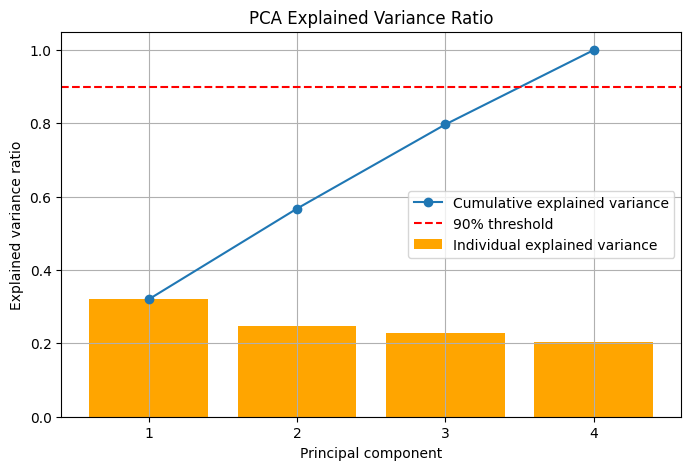

In [10]:
from sklearn.decomposition import PCA

# Fit PCA on scaled training data
pca = PCA()
X_train_pca = pca.fit_transform(X_train)

# Explained variance ratios
explained_var = pca.explained_variance_ratio_

# Get cumulative variances
cumulative_var = np.cumsum(explained_var)

# Minimum number of components needed for at least 90% variance
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1

print("Explained variance ratio:", explained_var)
print("Cumulative explained variance:", cumulative_var)
print("Number of components for at least 90% variance:", n_components_90)

# Plot explained variance ratio
plt.figure(figsize=(8, 5))

# Plot the explained variance of each component
plt.bar(
    range(1, len(explained_var) + 1),
    explained_var,
    label="Individual explained variance",
    color='orange'
)

# Plot the cumalative variance as you add components
plt.plot(
    range(1, len(cumulative_var) + 1),
    cumulative_var,
    marker="o",
    label="Cumulative explained variance"
)

# Plot threshold line
plt.axhline(y=0.90, linestyle="--", color='red', label="90% threshold")

plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA Explained Variance Ratio")
plt.xticks(range(1, len(explained_var) + 1))
plt.legend()
plt.grid(True)
plt.show()

## Question 6

/Users/vishalbhaga/Documents/University/Year 1/MIT801/Exam/ML/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/vishalbhaga/Documents/University/Year 1/MIT801/Exam/ML/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


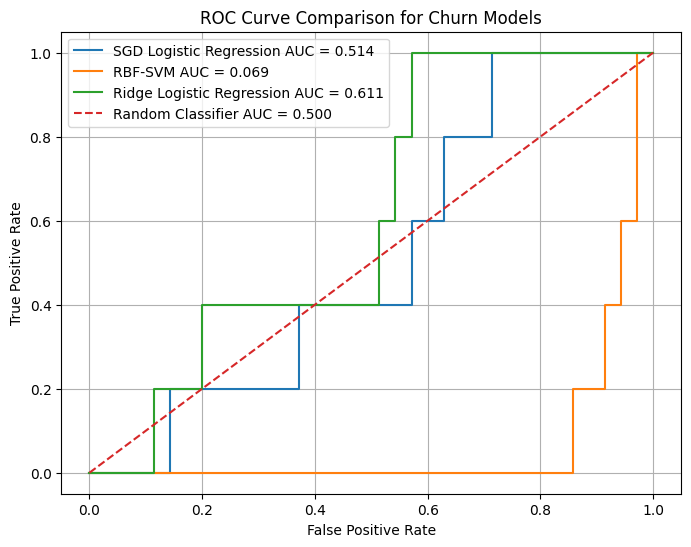

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression

# Define Models
sgd_logistic = SGDClassifier(
    loss="log_loss",
    learning_rate="optimal",
    max_iter=200,
    random_state=42
)

rbf_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

ridge_logistic = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

models = {
    "SGD Logistic Regression": sgd_logistic,
    "RBF-SVM": rbf_svm,
    "Ridge Logistic Regression": ridge_logistic
}

# Fit the Models and Plot ROC with AUC score
plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)

    # Get predicted probalities
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba) 
    roc_auc = roc_auc_score(y_test, y_test_proba)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{name} AUC = {roc_auc:.3f}")

# Add Baseline of AUC = 0.5 curve
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier AUC = 0.500")

# Plot the ROC curve
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Churn Models")
plt.legend()
plt.grid(True)
plt.show()